#**EXP NO:4 ASK**
#**NAME: HARSHADA P K**
#**REGISTER NUMBER: 212224060097**


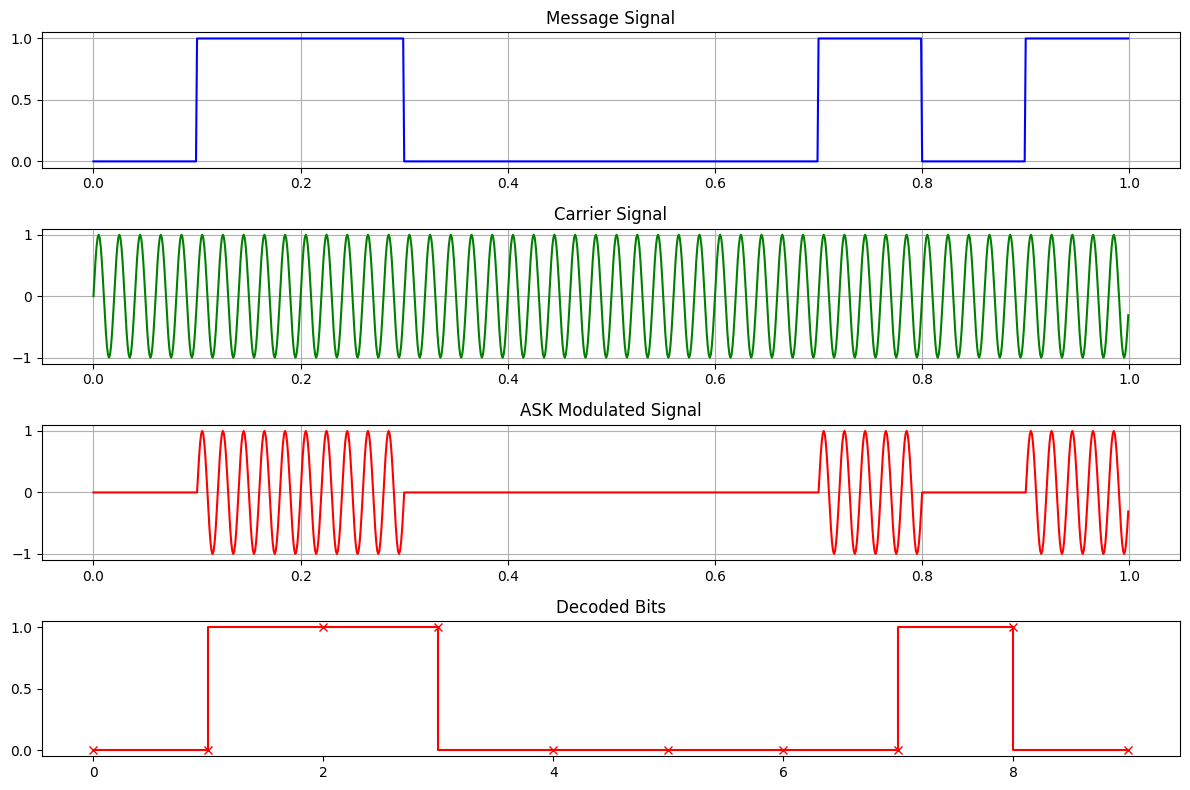

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
# Butterworth low-pass filter for demodulation
def butter_lowpass_filter(data, cutoff, fs, order=5):
  nyquist = 0.5*fs
  normal_cutoff = cutoff / nyquist
  b, a = butter(order, normal_cutoff, btype='low', analog=False)
  return lfilter(b, a, data)
# Parameters
fs = 1000 # Sampling frequency
f_carrier = 50 # Carrier frequency
bit_rate = 10 # Data rate
T = 1 # Total time duration
t = np.linspace(0, T, int(fs * T), endpoint=False)
# Message signal (binary data)
bits = np.random.randint(0, 2, bit_rate)
bit_duration = fs // bit_rate
message_signal = np.repeat(bits, bit_duration)
# Carrier signal
carrier = np.sin(2 * np.pi * f_carrier * t)
# ASK Modulation
ask_signal = message_signal * carrier
# ASK Demodulation
demodulated = ask_signal * carrier # Multiply by carrier for coherent detection
filtered_signal = butter_lowpass_filter(demodulated, f_carrier, fs)
decoded_bits = (filtered_signal[::bit_duration] > 0.25).astype(int)
# Plotting
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(t, message_signal, label='Message Signal (Binary)', color='b')
plt.title('Message Signal')
plt.grid(True)
plt.subplot(4, 1, 2)
plt.plot(t, carrier, label='Carrier Signal', color='g')
plt.title('Carrier Signal')
plt.grid(True)
plt.subplot(4, 1, 3)
plt.plot(t, ask_signal, label='ASK Modulated Signal', color='r')
plt.title('ASK Modulated Signal')
plt.grid(True)
plt.subplot(4, 1, 4)
plt.step(np.arange(len(decoded_bits)), decoded_bits, label='Decoded Bits', color='r', marker='x')
plt.title('Decoded Bits')
plt.tight_layout()
plt.show()
